**Example A**:
- We are going to use 2 layers
- optimizer we are going to use SGD
- We are going to use without Normalization

**Example B**:
- We are going to use 3 layers
- optimizer we are going to use Adam
- We are going to use without Normalization

**Example C**:
- We are going to use 2 layers
- optimizer we are going to use Adam
- We are going to use with Normalization and standardizatio


In [186]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split


In [187]:
insurance_data = pd.read_csv('/content/sample_data/insurance_data.csv')
insurance_data.head(3)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


In [188]:
insurance_data_one_hot = pd.get_dummies(insurance_data)
insurance_data_one_hot.head(3)

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.90,0,16884.9240,True,False,False,True,False,False,True
1,18,33.77,1,1725.5523,False,True,True,False,False,True,False
2,28,33.00,3,4449.4620,False,True,True,False,False,True,False


In [189]:
X = insurance_data_one_hot.drop('charges', axis=1)
y = insurance_data_one_hot['charges']


In [190]:
print('Features are: ')
X.head()

Features are: 


,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,True
1,18,33.770,1,False,True,True,False,False,True,False
2,28,33.000,3,False,True,True,False,False,True,False
3,33,22.705,0,False,True,True,False,True,False,False
4,32,28.880,0,False,True,True,False,True,False,False


In [191]:
print('Charges')
y.head()

Charges


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [192]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [193]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

In [194]:
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=['mae'])

In [195]:
model.fit(X_train, y_train, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step - loss: 8525.7100 - mae: 8525.7100
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 8500.1455 - mae: 8500.1455
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 8473.2627 - mae: 8473.2627
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 8427.7314 - mae: 8427.7314
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 8339.3691 - mae: 8339.3691
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 8163.3330 - mae: 8163.3330
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 7811.0215 - mae: 7811.0215
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 7105.3589 - mae: 7105.3589
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 5691.7524 - mae: 5691.7524
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 5436.3730 - mae: 5436.3730
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 5046.7573 - mae: 5046.7573
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 610

In [196]:
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 7740.6245 - mae: 7740.6245


[7740.62451171875, 7740.62451171875]

**Exercise B**

In [197]:
tf.random.set_seed(42)
model_2= tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model_2.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['mae'])

model_2.fit(X_train, y_train, epochs=150,verbose=0)

In [198]:
model_2.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 7693.5522 - mae: 7693.5522


[7693.55224609375, 7693.55224609375]

In [199]:
model_2_loss, model_2_mae = model_2.evaluate(X_test, y_test)
print('Loss: ', model_2_loss)
print('MAE: ', model_2_mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 7693.5522 - mae: 7693.5522
Loss:  7693.55224609375
MAE:  7693.55224609375


Text(0.5, 1.0, 'Loss vs Epochs')

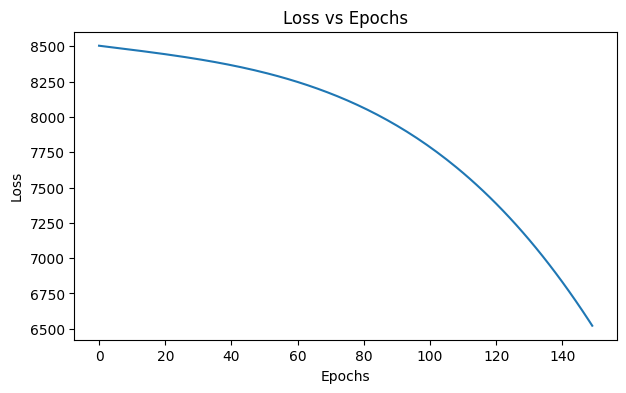

In [200]:
plt.figure(figsize=(7,4))
plt.plot(model_2.history.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')

**Example C**

In [201]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [202]:
ct  = make_column_transformer(
    (MinMaxScaler(), ['age', 'bmi', 'children']),
    (OneHotEncoder(handle_unknown='ignore'), ['sex', 'smoker', 'region'])
)

In [203]:
X = insurance_data.drop('charges', axis=1)
y = insurance_data['charges']

In [204]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [205]:
ct.fit(X_train)

ColumnTransformer(transformers=[('minmaxscaler', MinMaxScaler(),
                                 ['age', 'bmi', 'children']),
                                ('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['sex', 'smoker', 'region'])])

In [206]:
X_train_normal = ct.transform(X_train)
X_test_normal = ct.transform(X_test)

In [207]:
# Non-normalized data
X_train.shape
X_train

,age,sex,bmi,children,smoker,region
5,31,female,25.740,0,no,southeast
2,28,male,33.000,3,no,southeast
4,32,male,28.880,0,no,northwest
3,33,male,22.705,0,no,northwest


In [208]:
# Normalized data
X_train_normal

array([[0.6       , 0.2948033 , 0.        , 1.        , 0.        ,
        1.        , 0.        , 1.        ],
       [0.        , 1.        , 1.        , 0.        , 1.        ,
        1.        , 0.        , 1.        ],
       [0.8       , 0.59980573, 0.        , 0.        , 1.        ,
        1.        , 1.        , 0.        ],
       [1.        , 0.        , 0.        , 0.        , 1.        ,
        1.        , 1.        , 0.        ]])

In [185]:
tf.random.set_seed(42)
model_3= tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model_3.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['mae'])

model_3_history = model_3.fit(X_train_normal, y_train, epochs=200,verbose=0)

In [209]:
model_3.evaluate(X_test_normal, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - loss: 9162.7432 - mae: 9162.7432


[9162.7431640625, 9162.7431640625]

In [210]:
model_3_loss, model_3_mae = model_3.evaluate(X_test_normal, y_test)
print('Loss: ', model_3_loss)
print('MAE: ', model_3_mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 9162.7432 - mae: 9162.7432
Loss:  9162.7431640625
MAE:  9162.7431640625


Text(0.5, 1.0, 'Loss vs Epochs')

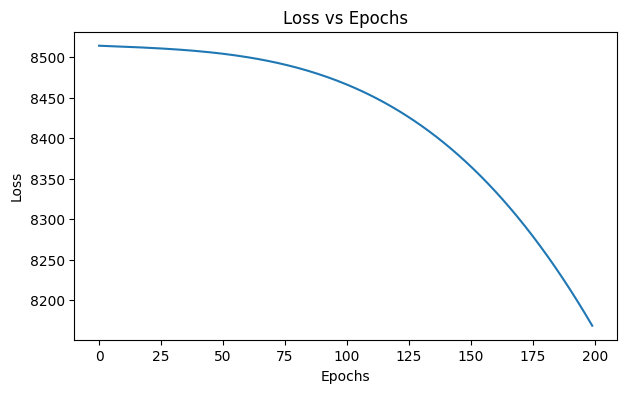

In [211]:
plt.figure(figsize=(7,4))
plt.plot(model_3.history.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')